# Fiscal and Monetary Policy with Heterogeneous Agents (ARS, 2025)

**Authors:** Adrien Auclert, Matthew Rognlie, and Ludwig Straub  
**Publication:** *Annual Review of Economics*, 17, 539–562 (2025)  
**Paper:** [Fiscal and Monetary Policy with Heterogeneous Agents](https://doi.org/10.1146/annurev-economics-091624-044646)

This notebook will develop a transparent Python implementation of the canonical Heterogeneous-Agent New Keynesian (HANK) framework reviewed by Auclert, Rognlie, and Straub (2025).

In [36]:
# Run once per kernel/environment. Standard-library modules (json, pathlib, etc.) need no installation.
import importlib.util
import subprocess
import sys

packages = {
    'numpy': 'numpy',
    'scipy': 'scipy',
    'matplotlib': 'matplotlib',
    'sequence_jacobian': 'sequence-jacobian',
}

missing = [pip_name for module, pip_name in packages.items()
           if importlib.util.find_spec(module) is None]

if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
else:
    print('All required packages are already installed.')


All required packages are already installed.


## 1. Households

The economy has a unit mass of households. They are ex-ante identical but become ex-post heterogeneous because they face uninsured idiosyncratic labor-productivity risk, $e_{it}$, and discount-factor risk, $\beta_{it}$. The joint state $(e,\beta)$ follows a Markov process, with independent productivity and discount-factor components and $\mathbb{E}[e_{it}]=1$. The analysis uses unexpected date-0 MIT shocks around the aggregate steady state, followed by perfect foresight; at first order, these are equivalent to impulse responses in the stochastic economy.

Households save through a mutual fund, cannot borrow, earn taxed labor income, and have logarithmic utility from consumption with separable labor disutility. Their problem is

$$\max_{\{c_{it},a_{it}\}}\; \mathbb{E}_0\sum_{t=0}^{\infty}\left(\prod_{s\leq t-1}\beta_{is}\right)\left[\log(c_{it})-v(n_{it})\right]$$

subject to

$$c_{it}+a_{it}\leq (1+r_t^p)a_{i,t-1}+(1-\tau_t)w_t e_{it}n_{it}, \qquad a_{it}\geq0. \tag{1}$$

Here $r_t^p$ is the ex-post mutual-fund return and $w_t$ is the pre-tax real wage per efficiency unit. In the baseline, unions—not individual households—set hours, so $n_{it}=n_t$. The borrowing constraint and income risk create buffer-stock saving behavior; discount-factor heterogeneity helps the model jointly match aggregate wealth, its distribution, and observed MPCs.

## 2. Firms, wage rigidity, and the Phillips curve

Firms use effective labor only: $Y_t=N_t$, where $N_t=\mathbb{E}[e_{it}n_{it}]$. They charge a constant markup $\mu$ over nominal marginal cost, which equals the nominal wage $W_t$. Thus $P_t=\mu W_t$, $w_t=1/\mu$, and after-tax real dividends are

$$d_t=(1-\tau_t)(Y_t-w_tN_t)=(1-\tau_t)\left(1-\frac{1}{\mu}\right)Y_t.$$

The paper assumes sticky **nominal wages**. A union allocates labor uniformly, $n_{it}=n_t$, and maximizes the utility of a household with average consumption $C_t=\int c_{it}\,di$, discounted at the average factor $\bar\beta$. Because prices remain a constant markup over wages, wage and price inflation coincide: $\pi_t^w=\pi_t$.

**How the wage Phillips curve arises (linearized, pedagogical derivation).**

1. The union's marginal disutility from one more unit of aggregate labor is $v'(N_t)$.
2. The marginal utility gain from the corresponding after-tax real wage is $\frac{1-\tau_t}{\mu C_t}$, using $u'(C_t)=1/C_t$ and $w_t=1/\mu$.
3. Define the wage-pressure gap in utility units as $x_t^w\equiv v'(N_t)-\frac{1-\tau_t}{\mu C_t}$. A positive gap means that the current nominal wage is too low relative to the union's desired wage.
4. Under **Calvo** wage setting, only a fraction of unions can reset each period. Aggregating reset-wage decisions and log-linearizing produces a forward-looking relation with slope $\kappa_C$, determined by the reset probability and steady-state objects.
5. Under **Rotemberg** wage adjustment costs, the union can reset every period but pays a quadratic cost for wage inflation. Its first-order condition, linearized around zero steady-state inflation, produces the same relation with slope $\kappa_R$, determined by adjustment-cost curvature.
6. Hence, with $\kappa\in\{\kappa_C,\kappa_R\}$ and perfect foresight after the MIT shock,

$$\pi_t^w=\kappa\left(v'(N_t)-\frac{1-\tau_t}{\mu C_t}\right)+\bar\beta\pi_{t+1}^w. \tag{2}$$

In a stochastic formulation, the final term is $\bar\beta\,\mathbb{E}_t[\pi_{t+1}^w]$. The adjustment-cost specification changes the mapping into $\kappa$, not the first-order structure used in this canonical presentation.

## 3. Fiscal authority

The government collects labor and corporate taxes at the common rate $\tau_t$, purchases $G_t$, and issues non-contingent real debt $B_t$ promising return $r_t$. Since total tax revenue is $\tau_tY_t$, its flow budget constraint is

$$G_t+B_t=(1+r_{t-1})B_{t-1}+\tau_tY_t. \tag{3}$$

Equivalently, the authority can specify compatible paths for $(G_t,\tau_t)$ or for $(G_t,B_t)$, with the remaining variable implied by the budget constraint and the intertemporal solvency condition. This formulation makes the fiscal incidence of a policy explicit: the tax path directly changes household disposable labor income and after-tax dividends.

## 4. Monetary authority

Monetary policy sets the real return $r_t$ on government bonds using a nominal-rate rule. The nominal policy rate $i_t$, real rate, and next-period inflation satisfy the Fisher identity

$$1+i_t=(1+r_t)(1+\pi_{t+1}).$$

For the paper's MIT experiments, a path for $r_t$ is an exogenous monetary-policy input. In an extension, a Taylor-type rule would determine $i_t$ as a function of inflation and/or output and, together with the Fisher identity and equation (2), would close the nominal side of the model.

## 5. Financial markets, market clearing, and equilibrium

The mutual fund pools household savings and invests them in the stock market and government bonds. Firm-value maximization gives the no-arbitrage condition

$$1+r_t=\frac{p_{t+1}+d_{t+1}}{p_t}. \tag{4}$$

With aggregate household assets $A_t=\int a_{it}\,di$, asset-market clearing is

$$A_t=p_t+B_t. \tag{5}$$

For $t\geq0$, fund competition implies $r_{t+1}^p=r_t$. The initial return adjusts to value the inherited portfolio:

$$(1+r_0^p)A=p_0+d_0+(1+r)B. \tag{6}$$

Goods-market clearing is

$$C_t+G_t=Y_t. \tag{7}$$

Given policy paths $\{r_t\}$ and $\{G_t,B_t\}$ consistent with equation (3), an equilibrium consists of aggregate prices and quantities $\{r_t^p,p_t,d_t,Y_t,C_t,A_t,\pi_t,W_t,N_t,i_t,\tau_t\}$, household policy functions, and a distribution over $(e,\beta,a)$ such that: (i) households solve (1); (ii) the distribution evolves under those policies and the Markov process; (iii) firms and unions satisfy production, pricing, and (2); (iv) fiscal and monetary conditions hold; and (v) (4)–(7) hold. Core parameters are the markup $\mu$, wage-rigidity slope $\kappa$, average discount factor $\bar\beta$, labor-disutility function $v(\cdot)$, idiosyncratic transition processes, and the borrowing limit. By Walras' law, one of the two market-clearing conditions (5) and (7) is redundant.

## 6. Sequence-space dependency graph (DAG)

The following cell draws the **baseline eight-block economy** assembled in the official code: seven common general-equilibrium blocks plus the HA household block. It treats policy paths and candidate equilibrium-price paths as inputs and places residuals at the end of the graph; this keeps the representation acyclic even though equilibrium itself is a fixed point.

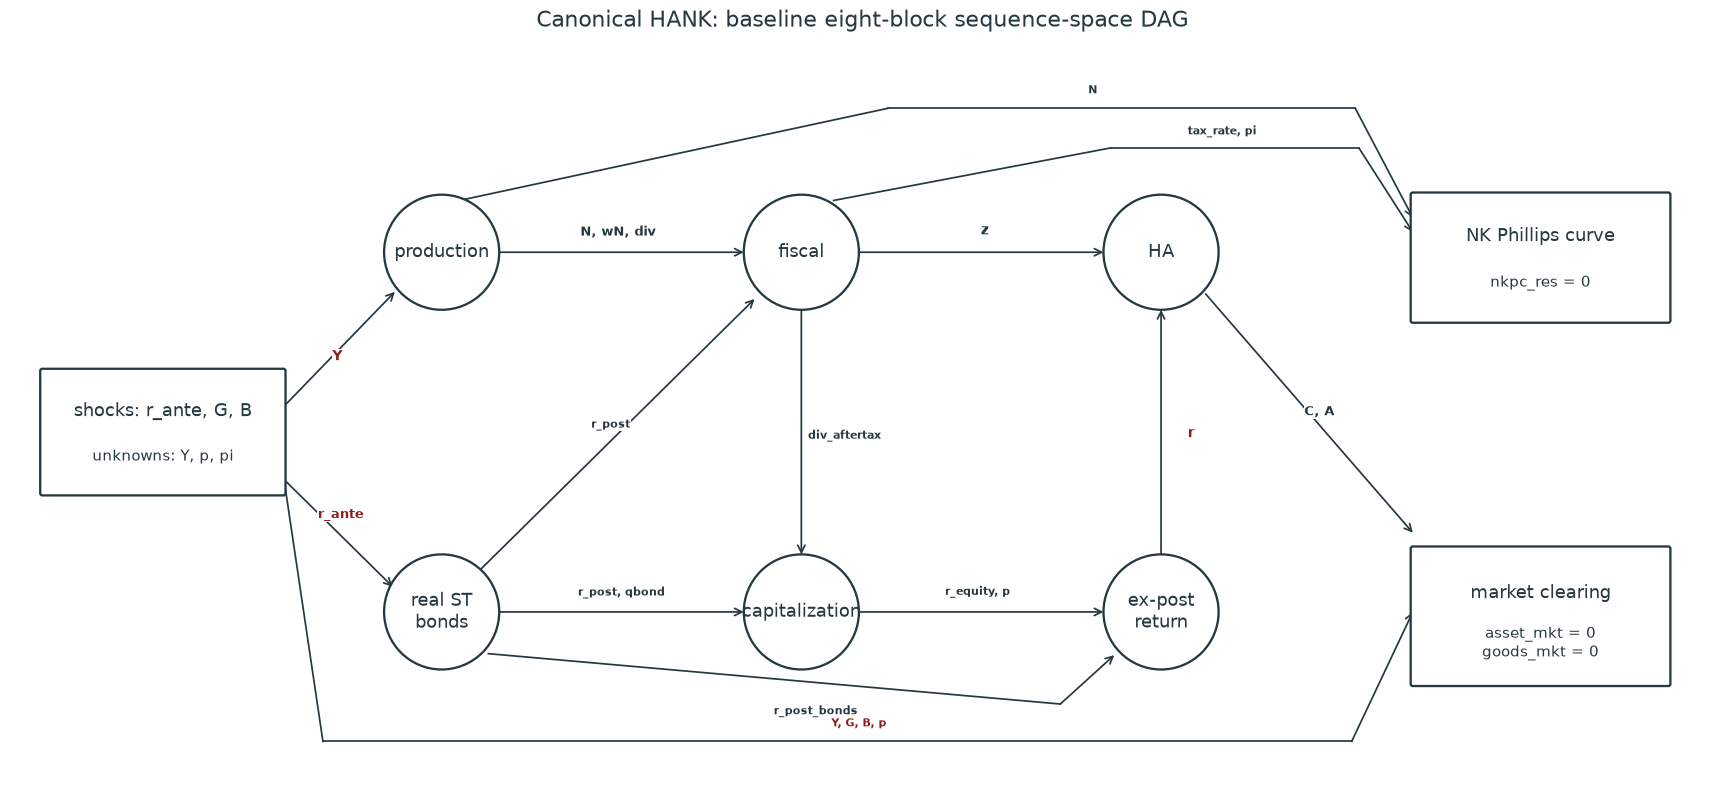

In [37]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch

# Baseline economy in Annual Review main.ipynb:
# production, real_ST_bonds, fiscal, capitalization, ex_post_r,
# nkpc, mkt_clearing, and hh_ha.
ink = '#263840'
accent = '#8B1E1E'

fig, ax = plt.subplots(figsize=(22, 10))

def arrow_path(points):
    for start, end in zip(points[:-2], points[1:-1]):
        ax.plot([start[0], end[0]], [start[1], end[1]], color=ink, lw=1.25)
    ax.add_patch(FancyArrowPatch(
        points[-2], points[-1], arrowstyle='->', mutation_scale=13,
        linewidth=1.25, color=ink, shrinkA=0, shrinkB=0,
    ))

def circle(x, y, text):
    ax.add_patch(Circle((x, y), radius=0.80, linewidth=1.65,
                        edgecolor=ink, facecolor='white', zorder=3))
    ax.text(x, y, text, ha='center', va='center', fontsize=13, color=ink, zorder=4)

def terminal(x, y, width, height, first, second):
    ax.add_patch(FancyBboxPatch(
        (x, y), width, height, boxstyle='round,pad=0.03', linewidth=1.65,
        edgecolor=ink, facecolor='white', zorder=3,
    ))
    ax.text(x + width / 2, y + 0.67 * height, first, ha='center', va='center',
            fontsize=13, color=ink, zorder=4)
    ax.text(x + width / 2, y + 0.30 * height, second, ha='center', va='center',
            fontsize=11, color=ink, zorder=4)

def label(x, y, text, color=ink, size=9):
    ax.text(x, y, text, fontsize=size, color=color, fontweight='bold',
            ha='center', va='center', zorder=5,
            bbox=dict(facecolor='white', edgecolor='none', pad=0.35, alpha=0.98))

# Exogenous paths and equilibrium unknowns.
terminal(0.45, 4.65, 3.35, 1.70, 'shocks: r_ante, G, B', 'unknowns: Y, p, pi')

# Baseline blocks: 7 common blocks plus the HA household block.
circle(6.00, 8.00, 'production')
circle(6.00, 3.00, 'real ST\nbonds')
circle(11.00, 8.00, 'fiscal')
circle(11.00, 3.00, 'capitalization')
circle(16.00, 3.00, 'ex-post\nreturn')
circle(16.00, 8.00, 'HA')
terminal(19.50, 7.05, 3.55, 1.75, 'NK Phillips curve', 'nkpc_res = 0')
terminal(19.50, 2.00, 3.55, 1.88, 'market clearing', 'asset_mkt = 0\ngoods_mkt = 0')

# Direct dependencies. Long connections are routed outside the core blocks.
arrow_path([(3.80, 5.85), (5.35, 7.45)])                      # inputs -> production
arrow_path([(3.80, 4.85), (5.32, 3.35)])                      # inputs -> bonds
arrow_path([(6.80, 8.00), (10.20, 8.00)])                     # production -> fiscal
arrow_path([(6.80, 3.00), (10.20, 3.00)])                     # bonds -> capitalization
arrow_path([(6.55, 3.60), (10.35, 7.35)])                     # bonds -> fiscal
arrow_path([(11.00, 7.20), (11.00, 3.80)])                    # fiscal -> capitalization
arrow_path([(11.80, 3.00), (15.20, 3.00)])                    # capitalization -> ex-post return
arrow_path([(6.65, 2.42), (14.60, 1.72), (15.35, 2.40)])      # bonds -> ex-post return
arrow_path([(11.80, 8.00), (15.20, 8.00)])                    # fiscal -> HA
arrow_path([(16.00, 3.80), (16.00, 7.20)])                    # ex-post return -> HA
arrow_path([(6.25, 8.72), (12.20, 10.00), (18.70, 10.00), (19.50, 8.48)])
arrow_path([(11.45, 8.72), (15.30, 9.45), (18.75, 9.45), (19.50, 8.28)])
arrow_path([(16.62, 7.42), (19.50, 4.10)])                    # HA -> market clearing
arrow_path([(3.80, 4.90), (4.35, 1.20), (18.65, 1.20), (19.50, 3.00)])

# Labels: shortened interfaces keep the graph readable.
label(4.55, 6.55, 'Y', accent, 10)
label(4.60, 4.35, 'r_ante', accent, 9)
label(8.45, 8.28, 'N, wN, div')
label(8.50, 3.27, 'r_post, qbond', size=8)
label(8.35, 5.60, 'r_post', size=8)
label(11.60, 5.45, 'div_aftertax', size=8)
label(13.45, 3.28, 'r_equity, p', size=8)
label(11.20, 1.62, 'r_post_bonds', size=8)
label(13.55, 8.30, 'z', size=10)
label(16.42, 5.48, 'r', accent, 10)
label(18.20, 5.78, 'C, A', size=9)
label(15.05, 10.25, 'N', size=8)
label(16.85, 9.68, 'tax_rate, pi', size=8)
label(11.80, 1.45, 'Y, G, B, p', accent, 8)

ax.set_xlim(0, 23.7)
ax.set_ylim(0.65, 10.75)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Canonical HANK: baseline eight-block sequence-space DAG',
             fontsize=16, color=ink, pad=20)
plt.show()


## Reading the DAG: code-to-model mapping

The DAG's eight blocks correspond directly to the baseline assembly in the official implementation. Seven general-equilibrium blocks are combined with the heterogeneous-household block, hh_ha.

| DAG block | Function in the official code | Economic role |
|:--|:--|:--|
| production | production(Y, mu) | Sets $N=Y$ and splits output into pre-tax wage income, wN, and dividends, div. |
| real ST bonds | real_ST_bonds(r_ante) | Maps the anticipated real rate into the realized bond return, r_post_bonds, and the bond price, qbond. |
| fiscal | fiscal(...) | Enforces the government budget constraint and computes tax revenue, tax_rate, wN_aftertax, and div_aftertax. |
| capitalization | capitalization(div_aftertax, r_ante, p) | Values firms as the present value of after-tax dividends and computes the realized equity return. |
| ex-post return | ex_post_r(...) | Aggregates realized equity and bond returns into the realized return on household wealth, $r_t$. |
| HA | hh_ha | Solves heterogeneous households' consumption and saving decisions and aggregates consumption, $C_t$, and assets, $A_t$. |
| NK Phillips curve | nkpc(...) | Computes the New Keynesian Phillips curve residual, nkpc_res. |
| market clearing | mkt_clearing(...) | Computes the asset-market and goods-market residuals. |

The baseline model is assembled as: common_blocks = [production, real_ST_bonds, fiscal, capitalization, ex_post_r, nkpc, mkt_clearing], followed by sj.combine(common_blocks + [hh_ha]).

The terminal equilibrium conditions in the DAG are

- Asset-market condition: $A_t-p_t-B_t=0$.
- Goods-market condition: $C_t+G_t-Y_t=0$.

The DAG is a computational representation: it displays how blocks map sequences of inputs to sequences of outputs and residuals. The sequence-space solver adjusts the relevant unknown paths until its target residuals are zero.

## Baseline HA calibration

The table below reproduces the baseline heterogeneous-agent calibration reported in Table 1 of Auclert, Rognlie, and Straub (2025). Annual values are explicitly labelled; all other flow rates use the paper's quarterly convention. The replication cell below uses the full-precision calibrated values saved by the official calibration notebook, rather than the rounded display values in this table.

| Symbol | Description | Value | Symbol | Description | Value |
|:--|:--|--:|:--|:--|--:|
| r | Real interest rate (annual) | 2% | μ | Markup | 1.11 |
| A | Assets to GDP (annual) | 500% | (βL, βH) | Discount factors (quarterly) | (0.91, 1.00) |
| B | Government bonds to GDP (annual) | 100% | ω | Share of patient households | 49% |
| M00 | Income-weighted MPC (quarterly) | 0.20 | q | Probability of a new β draw (quarterly) | 1% |
| G | Government spending to GDP | 20% | T | Taxes to GDP | 22% |

*Table 1. Calibration of the baseline HA model.*

In [38]:
# Faithful HA replication of the household calibration in the official ARS repository.
# This is a clean-room SSJ implementation: it reproduces the economic objects,
# parameter values, and public KMV income inputs, without importing repository code.

from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import sequence_jacobian as sj
from scipy import linalg

# Download only the two public KMV input files used by the official household block.
# The files are cached locally after the first execution.
official_raw = 'https://raw.githubusercontent.com/shade-econ/annual-review/main/inputs/kmv_process'
kmv_dir = Path('data') / 'ars_2025_kmv_process'
kmv_dir.mkdir(parents=True, exist_ok=True)
for filename in ('ymarkov_combined.txt', 'ygrid_combined.txt'):
    local_file = kmv_dir / filename
    if not local_file.exists():
        urlretrieve(f'{official_raw}/{filename}', local_file)

# Exact steady-state calibration reported by the official calibration notebook.
calibration_ha = {
    'eis': 1.0, 'min_a': 0.0, 'max_a': 4000.0, 'n_a': 200, 'r': 0.005,
    'q': 0.01, 'Tr_lumpsum': 0.0, 'Tax_richest': 0.0, 'zeta': 0.0,
    'N': 1.0, 'wN_aftertax': 0.70,
    'beta_hi': 0.9987628713512637,
    'dbeta': 0.08786014896166237,
    'omega': 0.4903451118386398,
}
calibration_ha['beta_ave'] = (calibration_ha['beta_hi']
                              - (1.0 - calibration_ha['omega']) * calibration_ha['dbeta'])

# Kaplan--Moll--Violante earnings process: a continuous-time generator converted
# to quarterly transition probabilities, then normalized to mean efficiency one.
Pi_e = linalg.expm(np.loadtxt(kmv_dir / 'ymarkov_combined.txt'))
Pi_e /= Pi_e.sum(axis=1, keepdims=True)
eigenvalues, eigenvectors = np.linalg.eig(Pi_e.T)
pi_e = np.real(eigenvectors[:, np.argmin(np.abs(eigenvalues - 1.0))])
pi_e /= pi_e.sum()
e_grid_short = np.exp(np.loadtxt(kmv_dir / 'ygrid_combined.txt'))
e_grid_short /= e_grid_short @ pi_e
n_e = e_grid_short.size

def beta_process(beta_hi, dbeta, omega, q):
    beta_values = np.array([beta_hi - dbeta, beta_hi])
    beta_stationary = np.array([1.0 - omega, omega])
    Pi_beta = (1.0 - q) * np.eye(2) + q * np.outer(np.ones(2), beta_stationary)
    return beta_values, beta_stationary, Pi_beta

@sj.het(exogenous='Pi', policy='a', backward='Va',
        backward_init=sj.hetblocks.hh_sim.hh_init)
def hh_ha_raw(Va_p, a_grid, y, r, beta, eis):
    expected_marginal_utility = beta[:, None] * Va_p
    consumption_next_grid = expected_marginal_utility ** (-eis)
    cash_on_hand = (1.0 + r) * a_grid[None, :] + y[:, None]
    a = sj.interpolate.interpolate_y(consumption_next_grid + a_grid, cash_on_hand, a_grid)
    sj.misc.setmin(a, a_grid[0])
    c = cash_on_hand - a
    Va = (1.0 + r) * c ** (-1.0 / eis)
    return Va, a, c

def make_ha_grids(min_a, max_a, n_a, beta_hi, dbeta, omega, q):
    a_grid = sj.grids.asset_grid(min_a, max_a, n_a)
    beta_values, beta_stationary, Pi_beta = beta_process(beta_hi, dbeta, omega, q)
    e_grid = np.kron(np.ones(2), e_grid_short)
    beta = np.kron(beta_values, np.ones(n_e))
    Pi = np.kron(Pi_beta, Pi_e)
    pi_pdf = np.kron(beta_stationary, pi_e)
    return e_grid, Pi, a_grid, beta, pi_pdf

def net_labor_income(wN_aftertax, N, e_grid, Tr_lumpsum, Tax_richest, zeta, pi_pdf):
    incidence = e_grid ** (zeta * np.log(N))
    incidence /= np.vdot(e_grid ** (1.0 + zeta * np.log(N)), pi_pdf)
    y = wN_aftertax * e_grid * incidence + Tr_lumpsum
    y = y.reshape(-1, n_e)
    y[:, -1] -= Tax_richest / pi_e[-1]
    y = y.ravel()
    return y

hh_ha = hh_ha_raw.add_hetinputs([make_ha_grids, net_labor_income])
hh_ha.name = 'hh_ha'
ss_ha = hh_ha.steady_state(calibration_ha)

# The official Figure 1 objects: the first column of the labor-income Jacobian
# and the interest-rate Jacobian divided by aggregate household assets.
T_ha = 26
M_labor = hh_ha.jacobian(ss_ha, inputs=['wN_aftertax'], outputs=['C'], T=T_ha)['C', 'wN_aftertax']
impc_income_ha = M_labor[:, 0]
impc_capital_ha = hh_ha.jacobian(ss_ha, inputs=['r'], outputs=['C'], T=T_ha)['C', 'r'][:, 0] / ss_ha['A']

# Model Lorenz curve, constructed from the stationary distribution over liquid assets.
D_assets = ss_ha.internals['hh_ha']['D'].sum(axis=0)
a_grid = ss_ha.internals['hh_ha']['a_grid']
population_share = np.concatenate(([0.0], np.cumsum(D_assets)))
wealth_share = np.concatenate(([0.0], np.cumsum(a_grid * D_assets) / ss_ha['A']))

ha_plot_data = {
    'impc_income': impc_income_ha,
    'impc_capital': impc_capital_ha,
    'population_share': population_share,
    'wealth_share': wealth_share,
}

print('Official-calibration HA steady state: '
      f'A / annual GDP = {ss_ha['A'] / 4.0:.2f}, '
      f'impact labor-income MPC = {impc_income_ha[0]:.3f}, '
      f'beta_low = {calibration_ha['beta_hi'] - calibration_ha['dbeta']:.6f}')


Official-calibration HA steady state: A / annual GDP = 5.00, impact labor-income MPC = 0.200, beta_low = 0.910903


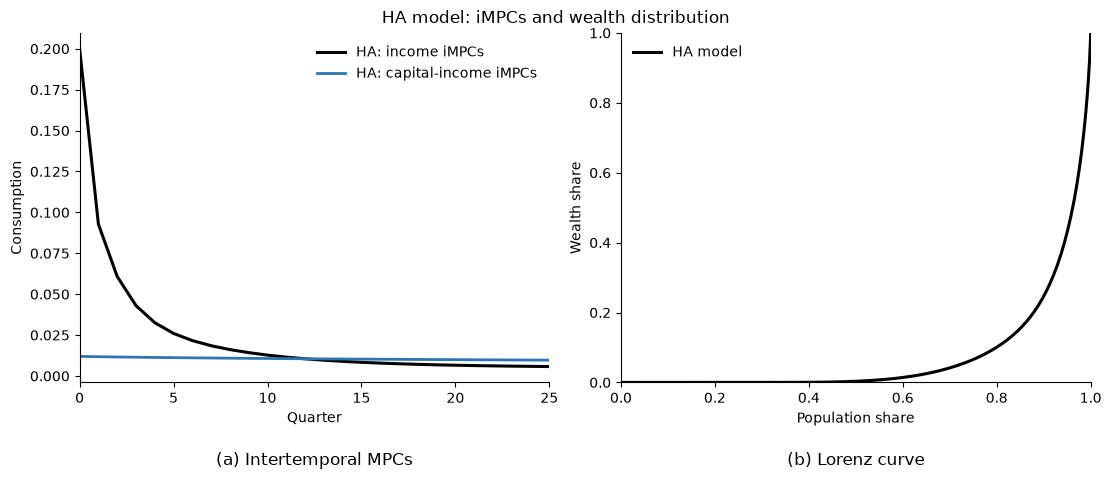

In [39]:
# HA-only version of Figure 1: run after the HA household block has been solved.
# Expected object:
# ha_plot_data = {
#     'impc_income': array_like,      # quarterly iMPCs out of labor income
#     'impc_capital': array_like,     # quarterly iMPCs out of capital gains
#     'population_share': array_like, # cumulative population share in [0, 1]
#     'wealth_share': array_like,     # cumulative wealth share in [0, 1]
# }

import numpy as np
import matplotlib.pyplot as plt

def plot_ha_diagnostics(ha_plot_data, max_quarters=25):
    required = {'impc_income', 'impc_capital', 'population_share', 'wealth_share'}
    missing = required.difference(ha_plot_data)
    if missing:
        raise KeyError(f'Missing HA plot inputs: {sorted(missing)}')

    impc_income = np.asarray(ha_plot_data['impc_income'], dtype=float)
    impc_capital = np.asarray(ha_plot_data['impc_capital'], dtype=float)
    population_share = np.asarray(ha_plot_data['population_share'], dtype=float)
    wealth_share = np.asarray(ha_plot_data['wealth_share'], dtype=float)

    horizon = min(max_quarters + 1, impc_income.size, impc_capital.size)
    quarters = np.arange(horizon)

    if population_share.shape != wealth_share.shape:
        raise ValueError('population_share and wealth_share must have the same shape.')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

    axes[0].plot(quarters, impc_income[:horizon], color='black', lw=2.2,
                 label='HA: income iMPCs')
    axes[0].plot(quarters, impc_capital[:horizon], color='#2E75B6', lw=2.0,
                 label='HA: capital-income iMPCs')
    axes[0].set(xlim=(0, max_quarters), xlabel='Quarter', ylabel='Consumption')
    axes[0].legend(frameon=False, loc='upper right')
    axes[0].spines[['top', 'right']].set_visible(False)
    axes[0].set_title('(a) Intertemporal MPCs', y=-0.26)

    axes[1].plot(population_share, wealth_share, color='black', lw=2.2,
                 label='HA model')
    axes[1].set(xlim=(0, 1), ylim=(0, 1), xlabel='Population share',
                ylabel='Wealth share')
    axes[1].legend(frameon=False, loc='upper left')
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].set_title('(b) Lorenz curve', y=-0.26)

    fig.suptitle('HA model: iMPCs and wealth distribution', y=1.03)
    plt.show()

if 'ha_plot_data' in globals():
    plot_ha_diagnostics(ha_plot_data)
else:
    print('Plot function ready. Define ha_plot_data after solving the HA block to render the figure.')


## 7. Fiscal policy: deficit-financed tax cuts

This section holds monetary policy at its steady-state real rate and studies first-order fiscal shocks. The paper distinguishes government-spending shocks from deficit shocks. The experiments below hold government spending fixed, $dG_t=0$, and implement a temporary tax cut financed by public debt.

With a fixed real rate, goods-market clearing and the household consumption Jacobian imply the intertemporal Keynesian cross: $dY = M(dY-dT)+dG$. For a balanced-budget spending increase, $dB=d r=0$ implies $dT=dG$, so the multiplier is one independently of household heterogeneity.

For Figure 2, excess debt follows $dB_t=\rho_B dB_{t-1}-dT_t^{shock}$, where $\rho_B=0.975$. The tax-cut shock is a one-percent-of-output shock decaying as $0.9^t$, while $G$ remains fixed. The code solves for the path of output that clears the asset market in each policy regime.

The replication below keeps the household model fixed at HA and compares fiscal incidence or the monetary/fiscal rule. It deliberately omits the two-agent and representative-agent comparison.

In [40]:
# Clean-room SSJ replication of ARS (2025), Figure 2: deficit-financed tax cuts.
# Run the preceding HA calibration cell first. This cell builds the full GE model.

@sj.simple
def production_ge(Y, mu):
    N = Y
    wN = Y / mu
    div = Y - wN
    return N, wN, div

@sj.simple
def real_st_bonds_ge(r_ante):
    r_post_bonds = r_ante(-1)
    qbond = 1.0 / (1.0 + r_ante)
    return r_post_bonds, qbond

@sj.simple
def fiscal_ge(B, r_post_bonds, G, Y, wN, div, tax_rate_shock, T_shock, T_rule_coeff, qbond):
    T = (1.0 + r_post_bonds) * B(-1) + G - B
    tax_rate = T / Y
    wN_aftertax = (1.0 - tax_rate) * wN
    div_aftertax = (1.0 - tax_rate) * div
    tax_rate_res = tax_rate - tax_rate.ss - tax_rate_shock
    T_res = T - T.ss - T_rule_coeff * (B(-1) - B.ss) - T_shock
    constant_owed_res = B / qbond - B.ss / qbond.ss
    return T, tax_rate, wN_aftertax, div_aftertax, tax_rate_res, T_res, constant_owed_res

@sj.simple
def fiscal_richest_ge(B, r_post_bonds, G, Y, wN, div):
    tax_total = (1.0 + r_post_bonds) * B(-1) + G - B
    T = tax_total.ss
    Tax_richest = tax_total - T
    tax_rate = T / Y
    wN_aftertax = (1.0 - tax_rate) * wN
    div_aftertax = (1.0 - tax_rate) * div
    return T, tax_rate, wN_aftertax, div_aftertax, Tax_richest

@sj.solved(unknowns={'p': (0.001, 50.0)}, targets=['cap_cond'])
def capitalization_ge(div_aftertax, r_ante, p):
    cap_cond = p - (div_aftertax(+1) + p(+1)) / (1.0 + r_ante)
    r_post_equity = (div_aftertax + p) / p(-1) - 1.0
    return r_post_equity, cap_cond

@sj.simple
def ex_post_return_ge(r_post_equity, r_post_bonds, B, p):
    r = (p(-1) * r_post_equity + B(-1) * r_post_bonds) / (p(-1) + B(-1))
    return r

@sj.simple
def nkpc_ge(pi, kappa, N, Y, G, beta_ave, vscale, frisch, tax_rate, mu, eis):
    wedge = vscale * N ** (1.0 / frisch) - (1.0 - tax_rate) / mu * (Y - G) ** (-1.0 / eis)
    nkpc_res = kappa * wedge + beta_ave * pi(+1) - pi
    return nkpc_res

@sj.simple
def taylor_rule_ge(rstar, pi, phi):
    nominal_rate = rstar + phi * pi
    r_ante = nominal_rate - pi(+1)
    return r_ante

@sj.simple
def market_clearing_ge(A, Y, C, p, B, G):
    asset_mkt = A - p - B
    goods_mkt = C + G - Y
    return asset_mkt, goods_mkt

# Steady state of the full eight-block model (output is normalized to one).
Y_ge, r_ge, A_ge, B_ge, G_ge = 1.0, 0.005, 20.0, 4.0, 0.20
C_ge = Y_ge - G_ge
tax_ge = G_ge + r_ge * B_ge
equity_ge = A_ge - B_ge
div_post_ge = r_ge * equity_ge
div_ge = div_post_ge / (1.0 - tax_ge)
w_post_ge = (1.0 - tax_ge) * (1.0 - div_ge)
mu_ge = 1.0 / (1.0 - div_ge)
eis_ge, frisch_ge = 1.0, 1.0
vscale_ge = w_post_ge / C_ge ** (1.0 / eis_ge) / Y_ge ** (1.0 / frisch_ge)

ge_params = {
    'Y': Y_ge, 'r_ante': r_ge, 'A': A_ge, 'B': B_ge, 'G': G_ge, 'C': C_ge,
    'mu': mu_ge, 'eis': eis_ge, 'frisch': frisch_ge, 'vscale': vscale_ge,
    'pi': 0.0, 'kappa': 0.01, 'tax_rate_shock': 0.0, 'T_shock': 0.0,
    'zeta': 0.0, 'T_rule_coeff': 0.0, 'Tax_richest': 0.0,
}

common_blocks_ge = [production_ge, real_st_bonds_ge, fiscal_ge, capitalization_ge,
                    ex_post_return_ge, nkpc_ge, market_clearing_ge]
model_ha_ge = sj.combine(common_blocks_ge + [hh_ha])
ss_ha_ge = model_ha_ge.steady_state({**calibration_ha, **ge_params})

# Deficit-financed tax-cut experiment and HA Jacobian cache.
T_ge = 400
Js_ge = {'hh_ha': hh_ha.jacobian(ss_ha_ge, inputs=['wN_aftertax', 'N', 'r'], outputs=['C', 'A'], T=T_ge)}
rho_B_ge, rho_tax_ge = 0.975, 0.90
dT_shock_ge = -rho_tax_ge ** np.arange(T_ge)
dB_ge = np.empty(T_ge)
dB_ge[0] = -dT_shock_ge[0]
for t in range(1, T_ge):
    dB_ge[t] = rho_B_ge * dB_ge[t - 1] - dT_shock_ge[t]

irf_fiscal_baseline = model_ha_ge.solve_impulse_linear(
    ss_ha_ge, unknowns=['Y'], targets=['asset_mkt'], inputs={'B': dB_ge},
    outputs=['Y', 'r', 'wN', 'wN_aftertax'], Js=Js_ge
)
irf_baseline = irf_fiscal_baseline['Y']

# Alternative HA policies in Figure 2(b).
richest_blocks_ge = common_blocks_ge.copy()
richest_blocks_ge[2] = fiscal_richest_ge
model_richest_ge = sj.combine(richest_blocks_ge + [hh_ha])
irf_richest = model_richest_ge.solve_impulse_linear(
    ss_ha_ge, unknowns=['Y'], targets=['asset_mkt'], inputs={'B': dB_ge}, outputs=['Y'])['Y']

ss_taylor_ge = ss_ha_ge.copy()
ss_taylor_ge['phi'], ss_taylor_ge['rstar'] = 1.5, r_ge
model_taylor_ge = sj.combine(common_blocks_ge + [hh_ha, taylor_rule_ge])
irf_taylor = model_taylor_ge.solve_impulse_linear(
    ss_taylor_ge, unknowns=['Y', 'pi'], targets=['asset_mkt', 'nkpc_res'],
    inputs={'B': dB_ge}, outputs=['Y'], Js=Js_ge)['Y']

irf_alw = model_ha_ge.solve_impulse_linear(
    ss_ha_ge, unknowns=['Y', 'B'], targets=['asset_mkt', 'tax_rate_res'],
    inputs={'tax_rate_shock': dT_shock_ge}, outputs=['Y'], Js=Js_ge)['Y']

print('GE checks (HA): asset market = {:.2e}; goods market = {:.2e}; NKPC = {:.2e}'.format(
    ss_ha_ge['asset_mkt'], ss_ha_ge['goods_mkt'], ss_ha_ge['nkpc_res']))


GE checks (HA): asset market = 2.67e-10; goods market = 5.88e-07; NKPC = -2.22e-18


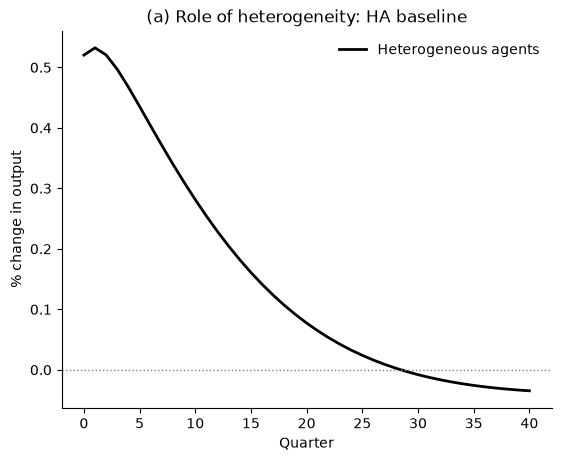

In [41]:
# Figure 2(a), HA only: baseline output response to a deficit-financed tax cut.
plot_horizon_ge = 41
quarters_ge = np.arange(plot_horizon_ge)
fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
ax.plot(quarters_ge, irf_baseline[:plot_horizon_ge], color='black', lw=2.0,
        label='Heterogeneous agents')
ax.axhline(0.0, color='gray', lw=1.0, ls=':')
ax.set(xlabel='Quarter', ylabel='% change in output',
       title='(a) Role of heterogeneity: HA baseline')
ax.legend(frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.show()


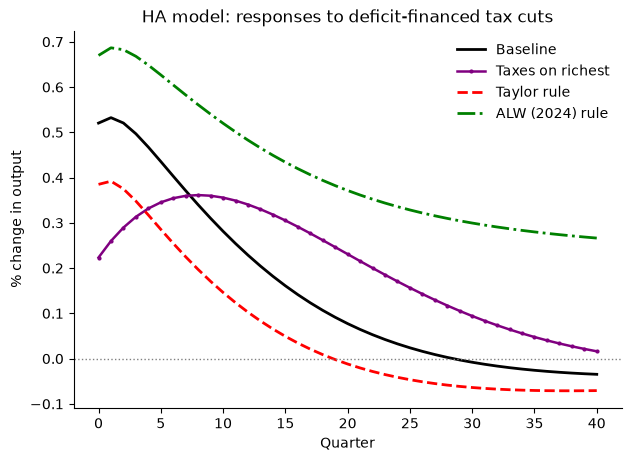

In [42]:
# Figure 2(b), HA only: output responses to the same deficit-financed tax cut.
plot_horizon_ge = 41
quarters_ge = np.arange(plot_horizon_ge)
fig, ax = plt.subplots(figsize=(6.2, 4.5), constrained_layout=True)

ax.plot(quarters_ge, irf_baseline[:plot_horizon_ge], color='black', lw=2.0, label='Baseline')
ax.plot(quarters_ge, irf_richest[:plot_horizon_ge], color='#800080', lw=1.8, marker='o',
        markersize=2, label='Taxes on richest')
ax.plot(quarters_ge, irf_taylor[:plot_horizon_ge], color='red', lw=2.0, ls='--', label='Taylor rule')
ax.plot(quarters_ge, irf_alw[:plot_horizon_ge], color='green', lw=2.0, ls='-.', label='ALW (2024) rule')
ax.axhline(0.0, color='gray', lw=1.0, ls=':')
ax.set(xlabel='Quarter', ylabel='% change in output',
       title='HA model: responses to deficit-financed tax cuts')
ax.legend(frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.show()


### Fiscal diagnostic decomposition (HA extension)

The official repository does not include this fiscal decomposition. This diagnostic applies the same SSJ accounting used for the monetary decomposition to the baseline deficit-financed tax-cut experiment. Government spending is fixed, so the household-consumption contributions sum to the output response.

The channels are: the unexpected impact return (capital gain), subsequent ex-post returns, pre-tax labor income, and the difference between after-tax and pre-tax labor income.

In [43]:
# HA diagnostic decomposition of the baseline fiscal shock.
dY_fiscal_capital_gains = Js_ge['hh_ha']['C', 'r'][:, 0] * irf_fiscal_baseline['r'][0]
dY_fiscal_interest = Js_ge['hh_ha']['C', 'r'][:, 1:] @ irf_fiscal_baseline['r'][1:]
dY_fiscal_labor = Js_ge['hh_ha']['C', 'wN_aftertax'] @ irf_fiscal_baseline['wN']
dY_fiscal_taxes = Js_ge['hh_ha']['C', 'wN_aftertax'] @ (
    irf_fiscal_baseline['wN_aftertax'] - irf_fiscal_baseline['wN']
)
dY_fiscal_channels = (dY_fiscal_capital_gains + dY_fiscal_interest
                      + dY_fiscal_labor + dY_fiscal_taxes)
if not np.allclose(dY_fiscal_channels, irf_baseline, atol=1e-8):
    raise AssertionError('Fiscal channels do not sum to the HA output response.')

print('HA fiscal decomposition check: max error = {:.2e}'.format(
    np.max(np.abs(dY_fiscal_channels - irf_baseline))))


HA fiscal decomposition check: max error = 1.33e-08


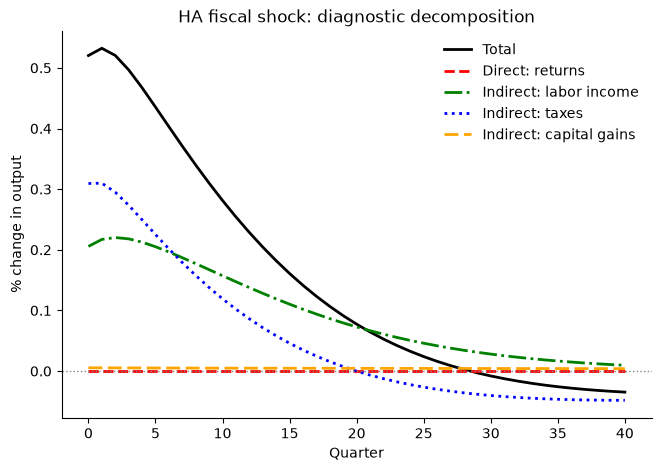

In [44]:
# Fiscal diagnostic decomposition: baseline deficit-financed tax cut in the HA model.
plot_horizon_fiscal_decomp = 41
quarters_fiscal_decomp = np.arange(plot_horizon_fiscal_decomp)
fig, ax = plt.subplots(figsize=(6.5, 4.6), constrained_layout=True)
ax.plot(quarters_fiscal_decomp, irf_baseline[:plot_horizon_fiscal_decomp], color='black', lw=2.0,
        label='Total')
ax.plot(quarters_fiscal_decomp, dY_fiscal_interest[:plot_horizon_fiscal_decomp], color='red', lw=2.0, ls='--',
        label='Direct: returns')
ax.plot(quarters_fiscal_decomp, dY_fiscal_labor[:plot_horizon_fiscal_decomp], color='green', lw=2.0, ls='-.',
        label='Indirect: labor income')
ax.plot(quarters_fiscal_decomp, dY_fiscal_taxes[:plot_horizon_fiscal_decomp], color='blue', lw=2.0, ls=':',
        label='Indirect: taxes')
ax.plot(quarters_fiscal_decomp, dY_fiscal_capital_gains[:plot_horizon_fiscal_decomp], color='orange', lw=2.0,
        ls=(0, (5, 2)), label='Indirect: capital gains')
ax.axhline(0.0, color='gray', lw=1.0, ls=':')
ax.set(xlabel='Quarter', ylabel='% change in output',
       title='HA fiscal shock: diagnostic decomposition')
ax.legend(frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.show()


## 8. Monetary policy: HA monetary easing

We study an exogenous cut in the anticipated real interest rate, holding fiscal policy as neutral as possible. With outstanding debt, a lower rate reduces the government's interest bill; the fiscal rule therefore chooses debt so that the real cash flow due in the next period remains at its steady-state value.

The monetary shock is $dr_t=-0.25\cdot0.9^t$. The first panel reports the HA output response. The second decomposes it into the direct interest-rate channel, indirect labor-income channel, indirect tax channel, and the unexpected period-zero capital-gain channel. By goods-market clearing, each consumption contribution is also an output contribution.

When steady-state government debt is zero, the paper's monetary-equivalence result makes the aggregate HA response coincide with the representative-agent benchmark. Here we retain the baseline positive-debt calibration, so the fiscal and return channels remain economically relevant.

In [45]:
# Clean-room SSJ replication of ARS (2025), Figure 3: HA monetary easing.
# Requires the preceding fiscal GE cell, which defines model_ha_ge, ss_ha_ge, and Js_ge.

dr_monetary = -0.25 * 0.90 ** np.arange(T_ge)
irf_monetary = model_ha_ge.solve_impulse_linear(
    ss_ha_ge, unknowns=['Y', 'B'], targets=['asset_mkt', 'constant_owed_res'],
    inputs={'r_ante': dr_monetary},
    outputs=['Y', 'r', 'wN', 'wN_aftertax'], Js=Js_ge
)

# HA decomposition. r[0] is the unanticipated ex-post return (capital gain);
# the remaining return path is the anticipated intertemporal substitution channel.
dY_capital_gains = Js_ge['hh_ha']['C', 'r'][:, 0] * irf_monetary['r'][0]
dY_interest = Js_ge['hh_ha']['C', 'r'][:, 1:] @ irf_monetary['r'][1:]
dY_labor = Js_ge['hh_ha']['C', 'wN_aftertax'] @ irf_monetary['wN']
dY_taxes = Js_ge['hh_ha']['C', 'wN_aftertax'] @ (
    irf_monetary['wN_aftertax'] - irf_monetary['wN']
)
decomposition_total = dY_capital_gains + dY_interest + dY_labor + dY_taxes
if not np.allclose(decomposition_total, irf_monetary['Y'], atol=1e-8):
    raise AssertionError('The monetary decomposition does not sum to the HA output response.')

print('HA monetary decomposition check: max error = {:.2e}'.format(
    np.max(np.abs(decomposition_total - irf_monetary['Y']))))


HA monetary decomposition check: max error = 1.23e-06


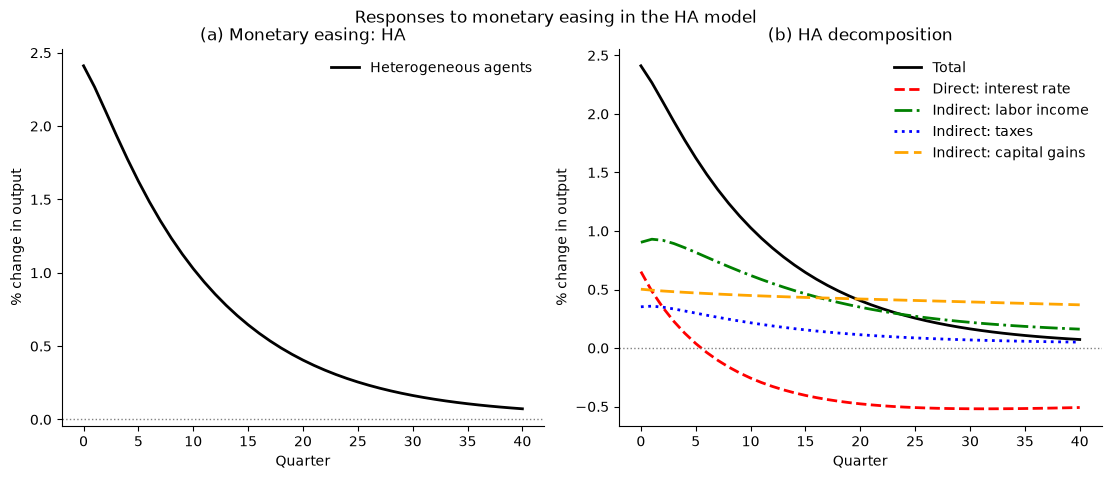

In [46]:
# Figure 3, HA only: monetary-easing response and its decomposition.
plot_horizon_mp = 41
quarters_mp = np.arange(plot_horizon_mp)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

axes[0].plot(quarters_mp, irf_monetary['Y'][:plot_horizon_mp], color='black', lw=2.0,
             label='Heterogeneous agents')
axes[0].axhline(0.0, color='gray', lw=1.0, ls=':')
axes[0].set(xlabel='Quarter', ylabel='% change in output',
            title='(a) Monetary easing: HA')
axes[0].legend(frameon=False, loc='upper right')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(quarters_mp, irf_monetary['Y'][:plot_horizon_mp], color='black', lw=2.0, label='Total')
axes[1].plot(quarters_mp, dY_interest[:plot_horizon_mp], color='red', lw=2.0, ls='--',
             label='Direct: interest rate')
axes[1].plot(quarters_mp, dY_labor[:plot_horizon_mp], color='green', lw=2.0, ls='-.',
             label='Indirect: labor income')
axes[1].plot(quarters_mp, dY_taxes[:plot_horizon_mp], color='blue', lw=2.0, ls=':',
             label='Indirect: taxes')
axes[1].plot(quarters_mp, dY_capital_gains[:plot_horizon_mp], color='orange', lw=2.0,
             ls=(0, (5, 2)), label='Indirect: capital gains')
axes[1].axhline(0.0, color='gray', lw=1.0, ls=':')
axes[1].set(xlabel='Quarter', ylabel='% change in output', title='(b) HA decomposition')
axes[1].legend(frameon=False, loc='upper right')
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Responses to monetary easing in the HA model', y=1.03)
plt.show()


## References

Auclert, A., Rognlie, M., & Straub, L. (2025). *Fiscal and Monetary Policy with Heterogeneous Agents*. Annual Review of Economics, 17, 539–562. [DOI](https://doi.org/10.1146/annurev-economics-091624-044646).

Auclert, A., Rognlie, M., & Straub, L. (2025). *Official replication repository: annual-review*. [GitHub](https://github.com/shade-econ/annual-review).

Auclert, A., Bardóczy, B., Rognlie, M., & Straub, L. (2021). *Using the Sequence-Space Jacobian to Solve and Estimate Heterogeneous-Agent Models*. Econometrica, 89(5), 2375–2408. [DOI](https://doi.org/10.3982/ECTA17434).